In [153]:
# Supressing warnings
import warnings
warnings.filterwarnings("ignore")

In [154]:
# Importing packages
import pandas as pd
import numpy as np

# Imporing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Read and Explore the Data

In [155]:
data = pd.read_csv('Housing.csv')

In [156]:
data.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [157]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [158]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Outlier Analysis

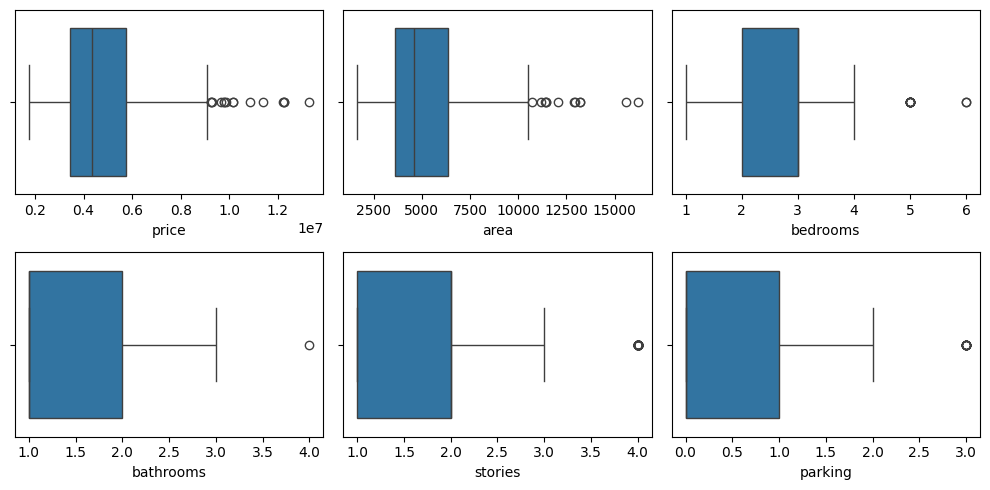

In [159]:
plt.figure(figsize=(10, 5))
plt.subplot(2,3,1)
sns.boxplot(data, x='price')
plt.subplot(2,3,2)
sns.boxplot(data, x='area')
plt.subplot(2,3,3)
sns.boxplot(data, x='bedrooms')
plt.subplot(2,3,4)
sns.boxplot(data, x='bathrooms')
plt.subplot(2,3,5)
sns.boxplot(data, x='stories')
plt.subplot(2,3,6)
sns.boxplot(data, x='parking')
plt.tight_layout()
plt.show()

price and area seems to have large number of outliers

In [160]:
# Removing outliers from price
q1_price = data.price.quantile(0.25)
q3_price = data.price.quantile(0.75)
iqr_price = q3_price - q1_price
lb_price = q1_price - (1.5*iqr_price)
ub_price = q3_price + (1.5*iqr_price)

print(f"Q1 price: {q1_price}")
print(f"Q3 price: {q3_price}")
print(f"IQR price: {iqr_price}")
print(f"Price lower bound: {lb_price}")
print(f"Price upper bound: {ub_price}")


Q1 price: 3430000.0
Q3 price: 5740000.0
IQR price: 2310000.0
Price lower bound: -35000.0
Price upper bound: 9205000.0


In [161]:
data = data[~((data.price <= lb_price) | (data.price >= ub_price))].reset_index(drop=True)

In [162]:
# Removing outliers from area
area_q1 = data.area.quantile(0.25)
area_q3 = data.area.quantile(0.75)
area_iqr = area_q3 - area_q1
lb_area = area_q1 - (1.5*area_iqr)
ub_area = area_q3 + (1.5*area_iqr)

print(f"Q1 area: {area_q1}")
print(f"Q3 area: {area_q3}")
print(f"IQR area: {area_iqr}")
print(f"Area lower bound: {lb_area}")
print(f"Area upper bound: {ub_area}")

Q1 area: 3547.5
Q3 area: 6315.75
IQR area: 2768.25
Area lower bound: -604.875
Area upper bound: 10468.125


In [163]:
data = data.loc[~((data.area <= lb_area) | (data.area >= ub_area))].reset_index(drop=True)

distribution after removing outliers in price & area

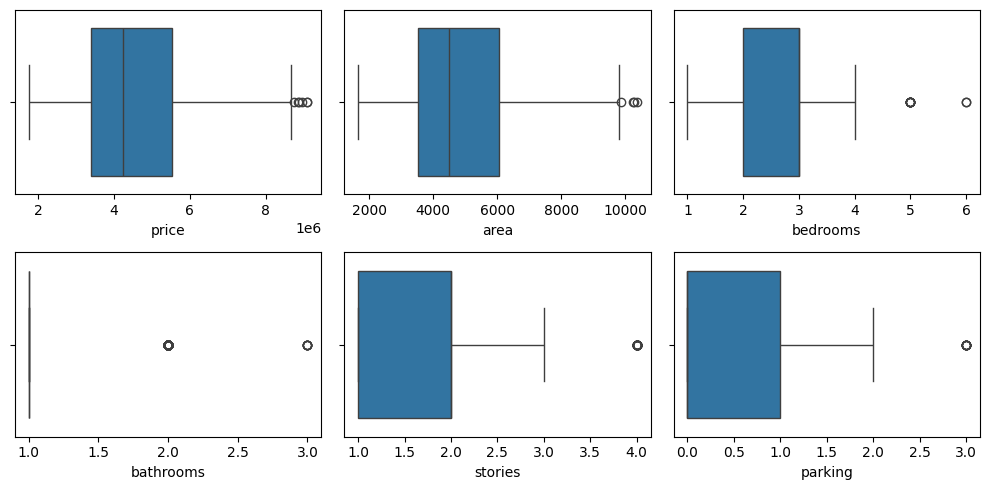

In [164]:
plt.figure(figsize=(10, 5))
plt.subplot(2,3,1)
sns.boxplot(data, x='price')
plt.subplot(2,3,2)
sns.boxplot(data, x='area')
plt.subplot(2,3,3)
sns.boxplot(data, x='bedrooms')
plt.subplot(2,3,4)
sns.boxplot(data, x='bathrooms')
plt.subplot(2,3,5)
sns.boxplot(data, x='stories')
plt.subplot(2,3,6)
sns.boxplot(data, x='parking')
plt.tight_layout()
plt.show()

In [165]:
# Correlation between price and numerical variables
data[['price', 'area', 'bedrooms', 'bathrooms', 'stories','parking']].corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.533186,0.335328,0.466483,0.446839,0.321058
area,0.533186,1.000000,0.127745,0.171528,0.109877,0.357276
bedrooms,0.335328,0.127745,1.000000,0.346230,0.406684,0.105561
bathrooms,0.466483,0.171528,0.346230,1.000000,0.311314,0.127102
stories,0.446839,0.109877,0.406684,0.311314,1.000000,0.022043
parking,0.321058,0.357276,0.105561,0.127102,0.022043,1.000000


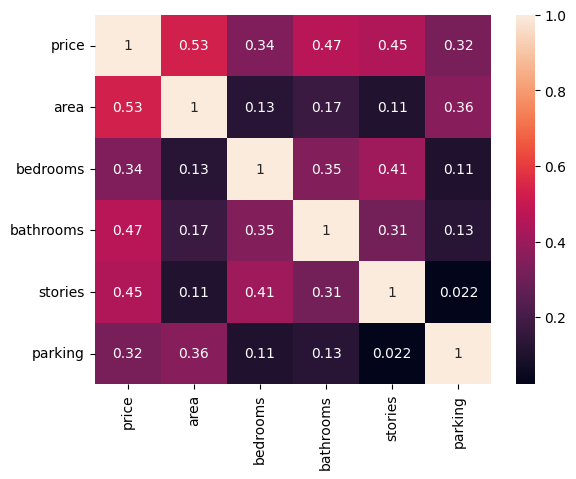

In [166]:

sns.heatmap(data[['price', 'area', 'bedrooms', 'bathrooms', 'stories','parking']].corr(), annot=True)
plt.show()

Visualizing categorical variables against price

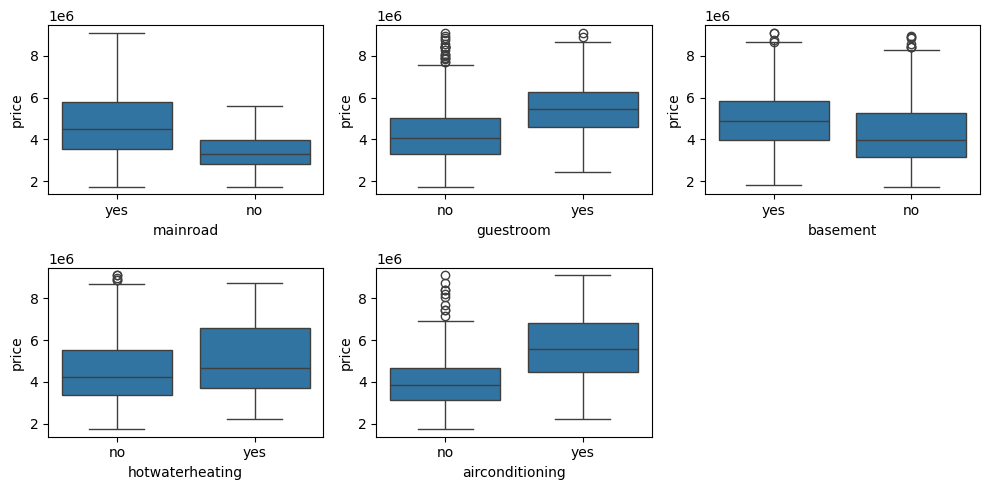

In [167]:
plt.figure(figsize=(10, 5))

plt.subplot(2,3,1)
sns.boxplot(data, x='mainroad', y='price')
plt.subplot(2,3,2)
sns.boxplot(data, x='guestroom', y='price')
plt.subplot(2,3,3)
sns.boxplot(data, x='basement', y='price')
plt.subplot(2,3,4)
sns.boxplot(data, x='hotwaterheating', y='price')
plt.subplot(2,3,5)
sns.boxplot(data, x='airconditioning', y='price')

plt.tight_layout()
plt.show()

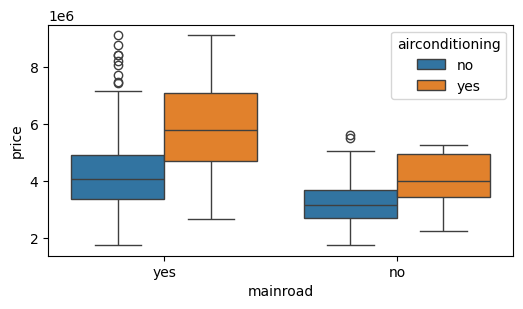

In [168]:
plt.figure(figsize=(6,3))
sns.boxplot(data, x='mainroad', y='price', hue='airconditioning')
plt.show()

Creating Features

In [169]:
print(data.info)
print(data.columns)

<bound method DataFrame.info of        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    9100000  6000         4          1        2      yes        no      yes   
1    9100000  6600         4          2        2      yes       yes      yes   
2    8960000  8500         3          2        4      yes        no       no   
3    8890000  4600         3          2        2      yes       yes       no   
4    8855000  6420         3          2        2      yes        no       no   
..       ...   ...       ...        ...      ...      ...       ...      ...   
512  1820000  3000         2          1        1      yes        no      yes   
513  1767150  2400         3          1        1       no        no       no   
514  1750000  3620         2          1        1      yes        no       no   
515  1750000  2910         3          1        1       no        no       no   
516  1750000  3850         3          1        2      yes        no       no   

    hot

In [170]:
categorical_variables = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

for cat in categorical_variables:
    print(data[cat].value_counts(), "\n")

mainroad
yes    440
no      77
Name: count, dtype: int64 

guestroom
no     425
yes     92
Name: count, dtype: int64 

basement
no     338
yes    179
Name: count, dtype: int64 

hotwaterheating
no     495
yes     22
Name: count, dtype: int64 

airconditioning
no     358
yes    159
Name: count, dtype: int64 

prefarea
no     405
yes    112
Name: count, dtype: int64 

furnishingstatus
semi-furnished    215
unfurnished       175
furnished         127
Name: count, dtype: int64 



In [171]:
binary_cat_variables = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

def transform_binary_variables(x):
    return x.map({'yes': 1, 'no': 0})

data[binary_cat_variables] = data[binary_cat_variables].apply(transform_binary_variables)

In [172]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished
1,9100000,6600,4,2,2,1,1,1,0,1,1,1,unfurnished
2,8960000,8500,3,2,4,1,0,0,0,1,2,0,furnished
3,8890000,4600,3,2,2,1,1,0,0,1,2,0,furnished
4,8855000,6420,3,2,2,1,0,0,0,1,1,1,semi-furnished


In [173]:
data_furnished = pd.get_dummies(data.furnishingstatus, drop_first=True)
data_furnished['semi-furnished'] = data_furnished['semi-furnished'].map({True: 1, False: 0})
data_furnished['unfurnished'] = data_furnished['unfurnished'].map({True: 1, False: 0})

In [174]:
data.drop(['furnishingstatus'], inplace=True, axis=1)

In [175]:
data = pd.concat([data, data_furnished], axis = 1)

In [176]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,9100000,6000,4,1,2,1,0,1,0,0,2,0,1,0
1,9100000,6600,4,2,2,1,1,1,0,1,1,1,0,1
2,8960000,8500,3,2,4,1,0,0,0,1,2,0,0,0
3,8890000,4600,3,2,2,1,1,0,0,1,2,0,0,0
4,8855000,6420,3,2,2,1,0,0,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
513,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
514,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
515,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


## Splitting Data into Train/Test subsets and Scaling

In [177]:
from sklearn.model_selection import train_test_split

Splitting Dataset

In [178]:
# Training subset 80%, Testing subset 20%
df_train, df_test = train_test_split(data, train_size=0.8, test_size=0.2, random_state=100) # must set random state, without it the samples may change in rerun

Scaling

In [179]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [180]:
# applying scalar to all numeric variables except the binary variables as they are already in range 0 to 1
num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
df_train[num_vars] = scaler.fit_transform(df_train[num_vars]) # we only fit the train data to scaler

In [181]:
df_test[num_vars] = scaler.transform(df_test[num_vars]) # for test data we only transform wrt training data, we do not fit the scaler

In [182]:
y_train = df_train.pop('price') # label for model / dependent variable
x_train = df_train # features for model / independent variables

In [183]:
y_test = df_test.pop('price') # label for test data
x_test = df_test # features for test data

## Fit the Linear Regression Model

In [184]:
from sklearn.linear_model import LinearRegression

In [185]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [187]:
print(model.coef_)

[2527088.9929434   193000.69186717 1520868.29320012 1471086.25857166
  387163.28407339  107665.08808556  320841.59283444  759920.54717187
  657331.9144279   517028.53121592  627668.26091734  -27828.72692791
 -407917.30736564]


Understanding the importance of Features

In [191]:
coeff = np.array(model.coef_)
importance = coeff/sum(coeff)
importance

array([ 0.29201677,  0.02230212,  0.17574333,  0.16999079,  0.0447385 ,
        0.0124412 ,  0.03707472,  0.08781232,  0.07595773,  0.05974503,
        0.07252996, -0.00321574, -0.04713672])

In [198]:
for i in range(len(x_train.columns)):
    print(f"Importance of {x_train.columns[i]}: {round(importance[i]*100, 2)}%")

Importance of area: 29.2%
Importance of bedrooms: 2.23%
Importance of bathrooms: 17.57%
Importance of stories: 17.0%
Importance of mainroad: 4.47%
Importance of guestroom: 1.24%
Importance of basement: 3.71%
Importance of hotwaterheating: 8.78%
Importance of airconditioning: 7.6%
Importance of parking: 5.97%
Importance of prefarea: 7.25%
Importance of semi-furnished: -0.32%
Importance of unfurnished: -4.71%


Intercept

In [199]:
intercept = model.intercept_
print(f"Intercept: {intercept}")

Intercept: 2189813.385515329


## Residual Analysis

residual analysis

Residual analysis is typically performed on the training data rather than the test data. 

The purpose of residual analysis is to assess the performance and

assumptions of your regression model during the training phase.

In [200]:
y_train_predicted = model.predict(x_train)

In [201]:
residuals = (y_train_predicted - y_train)

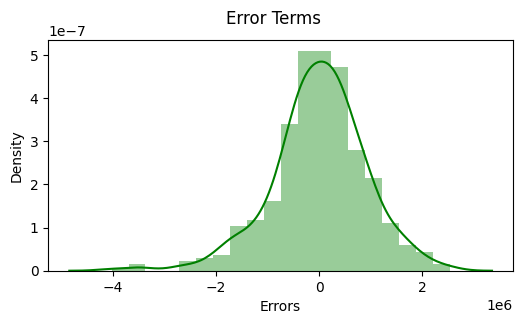

In [222]:
fig = plt.figure(figsize=(6,3))
sns.distplot(residuals, bins=20, color='green')
#sns.kdeplot(residuals, fill=True, color='green')
fig.suptitle('Error Terms')
plt.xlabel('Errors')
plt.show()

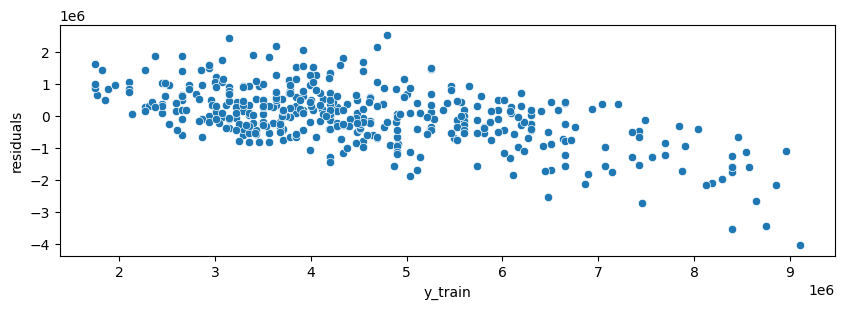

In [231]:
fig = plt.figure(figsize=(10,3))
#plt.scatter(y_train, residuals)
sns.scatterplot(x=y_train, y=residuals)
plt.xlabel('y_train')
plt.ylabel('residuals')
plt.show()

Model is giving negative error in high house price range and postive error in low house price range

Its estimating a bit higher prices for houses with lower prices and lower pricess for houses with higher prices

We might need more data or the relatioship between input and ouput is not necessarily linear in all regions

In the region where model is doing fine ( residual around 0) - we do have lot of data points

## Create Predictions and Evaluate Model

In [232]:
# Making predictions on test subset
y_test_pred = model.predict(x_test)

In [233]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

In [235]:
r2 = r2_score(y_test, y_test_pred)
print(f"R-Squared : {r2}")

R-Squared : 0.6463757490565982


In [236]:
mape = mean_absolute_percentage_error(y_test, y_test_pred)
print(f"Mean Absolute Percentage Error: {mape}")

Mean Absolute Percentage Error: 0.17229590487390156


Less than ~20% average percentage error is not a bad result on such a small dataset

Results would improve if we get more data to train the model

Some additional fetaures like distance from best school, shoppig and entertainment options etc would also help

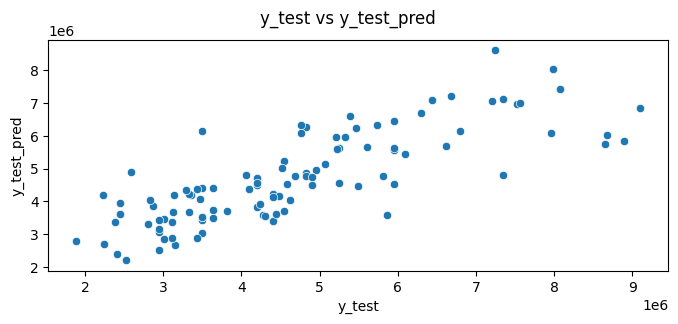

In [240]:
fig = plt.figure(figsize=(8, 3))
sns.scatterplot(x = y_test, y = y_test_pred)
plt.xlabel('y_test')
plt.ylabel('y_test_pred')
fig.suptitle("y_test vs y_test_pred")
plt.show()